# Your first simulation

This tutorial runs Monte Carlo on chignolin (PDB 1UAO), a 10-residue
β-hairpin that ships with pyMCPU, and then looks at what happened: the energy,
the acceptance rates and the structure. It takes about a minute to run. Run
the cells in order; each one uses the ones before it. Besides pyMCPU, it
needs matplotlib for the plots (`pip install matplotlib`).

Two conventions to keep in mind:

- **Temperature is a reduced, dimensionless number**, not Kelvin. Where a
  protein unfolds depends on the protein: chignolin melts at about 0.65 to
  0.7, as the [replica exchange tutorial](02_replica_exchange.ipynb) measures.
- **Energies are unitless.** They are sums of knowledge-based table entries,
  each term scaled by a weight.

## 1. Load a structure

pyMCPU reads structures with mdtraj. The engine works with heavy atoms only,
so remove the hydrogens; the hydrogen-bond term builds the amide hydrogens it
needs.

In [1]:
import numpy as np
import mdtraj as md

import pymcpu as mc
from pymcpu.forcefields.mcpu import MCPUForceField
from pymcpu.runners import default_example_pdb

pdb_path = str(default_example_pdb())  # chignolin, shipped with pyMCPU
structure = md.load(pdb_path)
heavy = structure.atom_slice(structure.topology.select("not element H"))

print(heavy.topology)
print("sequence:", heavy.topology.to_fasta()[0])

<mdtraj.Topology with 1 chains, 10 residues, 77 atoms, 80 bonds>
sequence: GYDPETGTWG


## 2. Build the force field and the system

`MCPUForceField` assigns an atom type to each atom, puts the atoms in the
order the engine works in, and loads the fitted potentials (parameter set
`mcpu08` by default). `create_system` returns a system with every energy term
registered:

In [2]:
forcefield = MCPUForceField(heavy)
system = forcefield.create_system(heavy.topology)

print(f"{system.get_num_atoms()} atoms, {system.get_num_residues()} residues")
for group, name in system.energy_terms().items():
    print(f"  term {group}: {name}")

77 atoms, 10 residues
  term 1: mu
  term 2: backbone_torsion
  term 3: sidechain_torsion
  term 4: hydrogen_bond
  term 5: aromatic


Each term scores one kind of interaction, from statistics of known protein
structures:

- `mu`: contacts between pairs of atoms, by atom type
- `backbone_torsion`: the backbone torsion angles of each residue, in the
  context of its neighbours
- `sidechain_torsion`: the side-chain torsion angles (χ)
- `hydrogen_bond`: backbone hydrogen bonds, scored by their geometry
- `aromatic`: stacking between the aromatic rings of PHE and TRP

[Physics background](../physics_notes/background.rst) describes each one.

## 3. Set up the simulation

`Integrator` holds the Monte Carlo settings: the temperature, which you must
give, the size of the backbone moves in radians, and the random seed. The
same seed, input and pyMCPU build reproduce a run exactly. `Simulation` ties
the topology, the system and the integrator together.

The engine takes one frame of coordinates, shaped `(3, n_atoms)`, in Å, as
float32. `forcefield.coords` already holds your structure in the engine's
atom order, in nm, so convert it rather than building the array yourself:

In [3]:
integrator = mc.Integrator(temperature=0.5, step_size_rad=0.1)
integrator.set_seed(42)

sim = mc.Simulation(heavy.topology, system, integrator)
sim.context.set_positions((forcefield.coords[0] * 10.0).T.astype(np.float32))

## 4. The starting energy

`energy_breakdown()` gives the energy of each term, by name, and the total.
With `weighted=True` each term is multiplied by its weight, as the engine adds
them up; `weighted=False` gives the raw table sums.

In [4]:
breakdown = sim.context.energy_breakdown(weighted=True)
for name, value in breakdown["by_name"].items():
    print(f"  {name:18} {value:9.3f}")
print(f"  {'total':18} {breakdown['weighted_total']:9.3f}")

  mu                    -3.458
  backbone_torsion      -3.275
  sidechain_torsion     -7.812
  hydrogen_bond         -0.161
  aromatic               0.000
  total                -14.707


`aromatic` is 0 because the term needs two of the rings it scores, and
chignolin has only one, Trp9.

## 5. Run

Each Monte Carlo step attempts one move, chosen at random: a pivot or a KIC
move of the backbone, or a rotamer move of a side chain, in proportions
1 : 1 : 2 by default. The 200,000 steps below take a few seconds for
chignolin.

Reporters write to files while the simulation runs. The energy reporter
writes a CSV row every `interval` steps, and the XTC reporter writes a
trajectory frame. `inverse_mapping` writes the frames in your topology's atom
order, so mdtraj can read them back with `heavy.topology`.

In [5]:
import os

os.makedirs("tutorial_output", exist_ok=True)
sim.add_energy_reporter("tutorial_output/energies.csv", interval=1000)
sim.add_xtc_reporter("tutorial_output/traj.xtc", interval=1000,
                     inverse_mapping=forcefield.inverse_mapping)

sim.step(200_000)
print(f"completed {sim.current_step} steps")

completed 200000 steps


To run this cell again, start again from step 3: running it twice attaches a
second pair of reporters to the same files, which corrupts them.

## 6. Is the run healthy?

Acceptance rates are the first thing to check. Judge `step_size_rad` by the
`pivot` rate: a rate of a few percent would mean the moves are too large for
the temperature, and one near 100% that they are too small to explore.

In [6]:
for kind, (accepted, attempted) in integrator.move_counts().items():
    if attempted:
        print(f"  {kind:10} {accepted:7d} / {attempted:7d}  {accepted / attempted:6.1%}")
    else:
        print(f"  {kind:10} off")

  pivot        21972 /   50196   43.8%
  rama_pivot off
  kic           3907 /   49308    7.9%
  rotamer      11061 /  100496   11.0%


Here 44% of pivot moves are accepted. The `kic` and `rotamer` rates are lower
for reasons `step_size_rad` does not change. Many KIC attempts are refused
before any energy is computed, for example when the loop would cross the
proline at position 4 (`integrator.move_stats()` counts these as
`kic_proline_skipped`). A rotamer move that picks one of the three glycines
has no side chain to move. `rama_pivot` is off unless you turn it on.

Then look at the energy over the run. The energy reporter only writes to
disk, so read its CSV back. It has a row for the starting structure and then
one every 1000 steps:

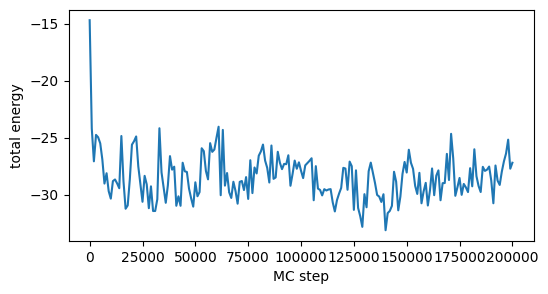

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

energies = pd.read_csv("tutorial_output/energies.csv")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(energies["step"], energies["total"])
ax.set_xlabel("MC step")
ax.set_ylabel("total energy")
plt.show()

The energy drops quickly from the starting structure and then fluctuates
around a steady value: the run has relaxed at this temperature. The CSV also
has a column for each energy term and the move counters, for example
`energies[["step", "mu", "hydrogen_bond"]]`.

## 7. What did the protein do?

The trajectory is an ordinary XTC file, so any analysis tool can read it.
With mdtraj, compute the RMSD of the Cα atoms from the starting structure,
which is the native one, and the radius of gyration:

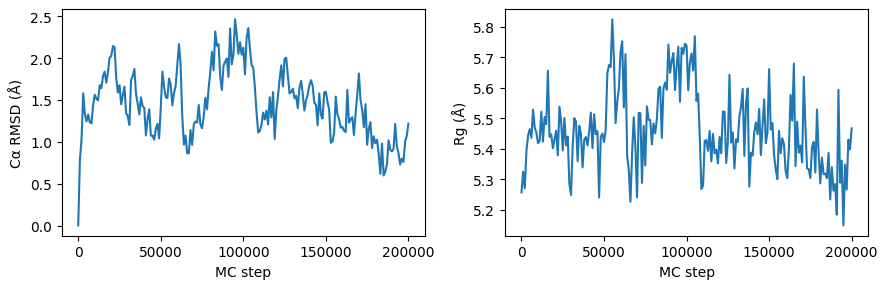

In [8]:
frames = md.load("tutorial_output/traj.xtc", top=heavy.topology)
ca = heavy.topology.select("name CA")
rmsd = md.rmsd(frames, heavy, atom_indices=ca) * 10  # nm -> Å
rg = md.compute_rg(frames) * 10
steps = np.arange(frames.n_frames) * 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(steps, rmsd)
ax1.set_xlabel("MC step")
ax1.set_ylabel("Cα RMSD (Å)")
ax2.plot(steps, rg)
ax2.set_xlabel("MC step")
ax2.set_ylabel("Rg (Å)")
fig.tight_layout()
plt.show()

At T = 0.5 the hairpin stays close to its native structure: the Cα RMSD
stays below about 2.5 Å, and the radius of gyration hardly changes.

## 8. Follow a quantity during a run

pyMCPU's collective variables work on the engine's coordinates. One of them
is Q, the fraction of the native contacts that are formed. A native contact
here is a pair of residues at least 4 apart in sequence whose Cα atoms are
within 8 Å of each other in the native structure; it counts as formed while
they are within 8 Å. The default cutoff is 6 Å; this tutorial sets 8 Å
(`contact_cutoff`), which counts more of chignolin's few contacts. Chignolin
has 11, so Q moves in steps of 1/11: 1 for the native structure, near 0 for
an unfolded chain.

In [9]:
from pymcpu.sampling import build_cv

q_of = build_cv(
    [{"type": "native_contacts_q", "reference_pdb": pdb_path, "contact_cutoff": 8.0}],
    forcefield,
)
print("Q now:", q_of(sim.context.coords)[0])

Q now: 1.0


After the run at T = 0.5, every native contact is still formed. A collective
variable takes coordinates in the engine's atom order, as `sim.context.coords`
holds them. For a frame read from the XTC file, put its atoms in engine order
first, `q_of((frames.xyz[i][forcefield.inverse_mapping] * 10).T)`; without
that, it still runs, but gives a wrong value.

To follow Q as a run goes, step in chunks and compute it in between. This
function runs chignolin from its native structure at one temperature:

In [10]:
def follow_q(temperature, n_steps=400_000, every=2_000, seed=1):
    """Return Q every `every` steps of a run from the native structure."""
    integrator = mc.Integrator(temperature=temperature, step_size_rad=0.1)
    integrator.set_seed(seed)
    run = mc.Simulation(heavy.topology, forcefield.create_system(heavy.topology), integrator)
    run.context.set_positions((forcefield.coords[0] * 10.0).T.astype(np.float32))
    q = [q_of(run.context.coords)[0]]
    for _ in range(n_steps // every):
        run.step(every)
        q.append(q_of(run.context.coords)[0])
    return np.array(q)

## 9. Temperature

Run it at three temperatures:

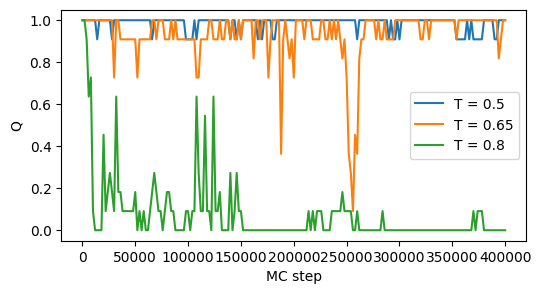

In [11]:
q_runs = {T: follow_q(T) for T in (0.5, 0.65, 0.8)}

fig, ax = plt.subplots(figsize=(6, 3))
for T, q in q_runs.items():
    ax.plot(np.arange(len(q)) * 2_000, q, label=f"T = {T}")
ax.set_xlabel("MC step")
ax.set_ylabel("Q")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.show()

At T = 0.5 the hairpin stays folded the whole time. At 0.8 it unfolds within
the first 10,000 steps and stays mostly unfolded. At 0.65, close to the
transition, it is mostly folded, but it loses contacts several times and once
unfolds almost completely before folding again.

A single run from the native structure shows what can happen, not how likely
each state is. Near the transition, a run has to cross between folded and
unfolded many times before its averages mean anything. Replica exchange, in
the [next tutorial](02_replica_exchange.ipynb), gets there much faster.

## Where to go next

- **Your own protein:** see "Using your own structure" in the
  [Quickstart](../quickstart.rst).
- **Replica exchange:** the [next tutorial](02_replica_exchange.ipynb).
- **Runs that outlast a job:** [Checkpointing and resume](../checkpointing.md).
- **Running from a config file:** [Command-line interface](../cli.rst).